# 🩸 Non-Invasive Glucose Estimation via PPG Signal
**Satria Data Competition — Statistics Essay Category**

---
## Dataset Structure
```
PPG_Dataset/
├── Figures/        → fig_XX_YYYY.jpg   (plot of each PPG recording)
├── Labels/         → label_XX_YYYY.mat (glucose ground truth per recording)
└── RawData/        → signal_XX_YYYY.mat (raw ADC signal, 10 sec @ 2190 Hz)
```
- `XX`   = Subject ID (e.g. 01, 02, 03 ...)
- `YYYY` = Recording number per subject (e.g. 0001, 0002 ...)

**Label = ONE glucose value per recording** (glucometer reading at time of capture, NOT per peak)

## Cell 1 — Imports & Config

In [1]:
!pip install numpy matplotlib scipy pandas

zsh:1: command not found: pip


In [2]:
import os
import glob
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG: point this to your dataset root ──
DATASET_ROOT = './'   # change if needed

RAW_DIR  = os.path.join(DATASET_ROOT, 'RawData')
LAB_DIR  = os.path.join(DATASET_ROOT, 'Labels')
FIG_DIR  = os.path.join(DATASET_ROOT, 'Figures')

FS       = 2190   # sampling frequency (Hz) — 21900 samples / 10 sec
DURATION = 10     # seconds per recording

print('Dataset root :', DATASET_ROOT)
print('Exists       :', os.path.exists(DATASET_ROOT))

Dataset root : ./
Exists       : True


## Cell 2 — Scan All Files & Count Recordings

In [3]:
# Find all signal files
signal_files = sorted(glob.glob(os.path.join(RAW_DIR, 'signal_*.mat')))
label_files  = sorted(glob.glob(os.path.join(LAB_DIR, 'label_*.mat')))

print(f'Total signal files : {len(signal_files)}')
print(f'Total label files  : {len(label_files)}')
print()

# Parse subject IDs from filenames
def parse_id(filepath):
    """Extract (subject_id, recording_id) from filename like signal_01_0003.mat"""
    name = os.path.basename(filepath)         # signal_01_0003.mat
    parts = name.replace('.mat','').split('_') # ['signal','01','0003']
    return int(parts[1]), int(parts[2])        # (1, 3)

subjects = {}
for f in signal_files:
    subj, rec = parse_id(f)
    subjects.setdefault(subj, []).append(rec)

print('Subjects found:')
for subj, recs in subjects.items():
    print(f'  Subject {subj:02d} → {len(recs)} recordings: {recs}')

print(f'\nTotal subjects     : {len(subjects)}')
print(f'Total recordings   : {sum(len(v) for v in subjects.values())}')

Total signal files : 67
Total label files  : 67

Subjects found:
  Subject 01 → 7 recordings: [1, 2, 3, 4, 5, 6, 7]
  Subject 02 → 3 recordings: [1, 2, 3]
  Subject 03 → 2 recordings: [1, 2]
  Subject 04 → 5 recordings: [1, 2, 3, 4, 5]
  Subject 05 → 6 recordings: [1, 2, 3, 4, 5, 6]
  Subject 06 → 2 recordings: [1, 2]
  Subject 07 → 4 recordings: [1, 2, 3, 4]
  Subject 08 → 2 recordings: [1, 2]
  Subject 09 → 2 recordings: [1, 2]
  Subject 10 → 2 recordings: [1, 2]
  Subject 11 → 4 recordings: [1, 2, 3, 4]
  Subject 12 → 1 recordings: [1]
  Subject 13 → 2 recordings: [1, 2]
  Subject 14 → 2 recordings: [1, 2]
  Subject 15 → 3 recordings: [1, 2, 3]
  Subject 16 → 3 recordings: [1, 2, 3]
  Subject 17 → 2 recordings: [1, 2]
  Subject 18 → 3 recordings: [1, 2, 3]
  Subject 19 → 2 recordings: [1, 2]
  Subject 20 → 3 recordings: [1, 2, 3]
  Subject 21 → 2 recordings: [1, 2]
  Subject 22 → 3 recordings: [1, 2, 3]
  Subject 23 → 2 recordings: [1, 2]

Total subjects     : 23
Total recordings   

## Cell 3 — Inspect a Single Signal File

In [4]:
# Load one signal file and print everything inside
sample_signal_path = signal_files[0]
print('File:', os.path.basename(sample_signal_path))
print('─' * 40)

mat = sio.loadmat(sample_signal_path)

print('Keys in .mat file:')
for key, val in mat.items():
    if key.startswith('_'):
        continue   # skip metadata keys like __header__, __version__
    arr = np.array(val)
    print(f'  [{key}]')
    print(f'    shape  : {arr.shape}')
    print(f'    dtype  : {arr.dtype}')
    print(f'    min    : {arr.min()}')
    print(f'    max    : {arr.max()}')
    print(f'    mean   : {arr.mean():.2f}')
    print(f'    sample : {arr.flatten()[:8]} ...')

signal = mat['signal'].flatten().astype(float)
time   = np.arange(len(signal)) / FS

print(f'\nDerived info:')
print(f'  Sampling rate : {FS} Hz')
print(f'  Duration      : {len(signal)/FS:.1f} seconds')
print(f'  Total samples : {len(signal)}')

File: signal_01_0001.mat
────────────────────────────────────────
Keys in .mat file:
  [signal]
    shape  : (21900, 1)
    dtype  : uint16
    min    : 495
    max    : 526
    mean   : 511.87
    sample : [503 503 503 502 502 502 502 502] ...

Derived info:
  Sampling rate : 2190 Hz
  Duration      : 10.0 seconds
  Total samples : 21900


## Cell 4 — Load Labels and Build the Native-Rate Feature Table

Labels are MATLAB MCOS `table` objects. `scipy.io.loadmat` and `pymatreader`
both return them undecoded; GNU Octave (even with `tablicious`) also fails.
`mat-io` decodes them correctly — see `rppg/data/convert_labels.py`. Run it
once (already committed as `rppg/data/labels.csv`) and load the reusable
pipeline modules.

In [5]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))  # repo root, so `import rppg...` works
import pandas as pd

from rppg.data import loader, convert_labels
from rppg.features import extractor
from rppg.evaluate import metrics

# labels.csv is committed; regenerate only if missing
if not os.path.exists(loader.LABELS_CSV):
    convert_labels.convert_all()

labels_df = loader.load_labels()
convert_labels.print_distribution(labels_df)

records = loader.load_all_recordings()
print(f'\nLoaded {len(records)} recordings from {len(set(r["subject_id"] for r in records))} subjects')

n recordings   : 67
n subjects     : 23
glucose_mgdl   : min=88.0  max=183.0  mean=115.0  std=18.7
histogram:
  [  88.0,   97.5) : ####### (7)
  [  97.5,  107.0) : #################### (20)
  [ 107.0,  116.5) : ################ (16)
  [ 116.5,  126.0) : ####### (7)
  [ 126.0,  135.5) : ####### (7)
  [ 135.5,  145.0) : ###### (6)
  [ 145.0,  154.5) : ## (2)
  [ 154.5,  164.0) :  (0)
  [ 164.0,  173.5) :  (0)
  [ 173.5,  183.0) : ## (2)

Loaded 67 recordings from 23 subjects


In [6]:
FEATURE_COLS = [
    'pulse_rate_bpm', 'hrv_rmssd_ms', 'perfusion_index',
    'signal_quality', 'rise_time_ms', 'pulse_width_half_ms',
]

rows = []
for r in records:
    feats = extractor.extract_features(r['signal'], loader.FS_NATIVE)
    row = {'subject_id': r['subject_id'], 'recording_id': r['recording_id'],
           'glucose_mgdl': r['glucose_mgdl']}
    row.update(feats)
    rows.append(row)

df_native = pd.DataFrame(rows)
print(f'Feature table: {df_native.shape[0]} recordings x {len(FEATURE_COLS)} features')
print('\nFeature availability (native 2190 Hz) — fraction non-NaN:')
print(df_native[FEATURE_COLS].notna().mean().round(3))
df_native.head()

Feature table: 67 recordings x 6 features

Feature availability (native 2190 Hz) — fraction non-NaN:
pulse_rate_bpm         1.0
hrv_rmssd_ms           1.0
perfusion_index        1.0
signal_quality         1.0
rise_time_ms           1.0
pulse_width_half_ms    1.0
dtype: float64


,subject_id,recording_id,glucose_mgdl,pulse_rate_bpm,hrv_rmssd_ms,perfusion_index,signal_quality,rise_time_ms,pulse_width_half_ms,n_beats_detected
0,1,1,99.0,79.5,28.208674,4.730956,0.702343,203.767123,135.882801,13
1,1,2,102.0,72.0,158.458494,6.421025,0.078522,202.942669,167.326230,10
2,1,3,103.0,73.5,46.810304,3.852815,0.629153,205.147364,141.511000,12
3,1,4,128.0,85.5,51.086780,9.714298,0.570119,160.028100,131.260976,14
4,1,5,130.0,78.0,81.382083,4.076872,0.130217,174.657534,150.722983,13


## Cell 5 — Subject-Disjoint Split (GroupKFold) — Native Rate

In [7]:
from sklearn.model_selection import GroupKFold

X_native = df_native[FEATURE_COLS].values
y_native = df_native['glucose_mgdl'].values
groups_native = df_native['subject_id'].values

N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

print(f'Verifying {N_SPLITS}-fold GroupKFold is subject-disjoint (23 subjects, ~{23//N_SPLITS} held out per fold):')
for fold_i, (train_idx, test_idx) in enumerate(gkf.split(X_native, y_native, groups_native)):
    metrics.assert_group_disjoint(groups_native, train_idx, test_idx)  # raises on any leakage
    train_subjects = sorted(set(groups_native[train_idx]))
    test_subjects = sorted(set(groups_native[test_idx]))
    print(f'  fold {fold_i}: {len(train_subjects)} train subjects, '
          f'{len(test_subjects)} test subjects, overlap={set(train_subjects) & set(test_subjects)}')
print('PASS: all folds are subject-disjoint (no participant appears in both train and test of any fold).')

Verifying 5-fold GroupKFold is subject-disjoint (23 subjects, ~4 held out per fold):
  fold 0: 19 train subjects, 4 test subjects, overlap=set()
  fold 1: 19 train subjects, 4 test subjects, overlap=set()
  fold 2: 18 train subjects, 5 test subjects, overlap=set()
  fold 3: 18 train subjects, 5 test subjects, overlap=set()
  fold 4: 18 train subjects, 5 test subjects, overlap=set()
PASS: all folds are subject-disjoint (no participant appears in both train and test of any fold).


## Cell 6 — Native-Rate Models: Population-Mean Baseline vs Ridge vs Random Forest

Per finding C3, no regression result is meaningful without a trivial
baseline in the same table. `DummyRegressor(strategy='mean')` run through
the same grouped, leakage-free CV is that baseline here.

In [8]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

baseline_pipe = make_pipeline(SimpleImputer(strategy='median'), DummyRegressor(strategy='mean'))
ridge_pipe = make_pipeline(SimpleImputer(strategy='median'), StandardScaler(), Ridge(alpha=1.0))
rf_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42))

pred_baseline = cross_val_predict(baseline_pipe, X_native, y_native, groups=groups_native, cv=gkf)
pred_ridge = cross_val_predict(ridge_pipe, X_native, y_native, groups=groups_native, cv=gkf)
pred_rf = cross_val_predict(rf_pipe, X_native, y_native, groups=groups_native, cv=gkf)

results_native = df_native[['subject_id', 'recording_id', 'glucose_mgdl']].copy()
results_native['pred_baseline'] = pred_baseline
results_native['pred_ridge'] = pred_ridge
results_native['pred_rf'] = pred_rf
for col in ['baseline', 'ridge', 'rf']:
    results_native[f'abs_err_{col}'] = (results_native[f'pred_{col}'] - results_native['glucose_mgdl']).abs()

print('Pooled MAE (native rate, out-of-fold):')
for col in ['baseline', 'ridge', 'rf']:
    print(f'  {col:10s}: {results_native[f"abs_err_{col}"].mean():.2f} mg/dL')

Pooled MAE (native rate, out-of-fold):
  baseline  : 14.57 mg/dL
  ridge     : 15.64 mg/dL
  rf        : 16.52 mg/dL


In [9]:
print('Per-subject MAE (native rate):\n')
for col in ['baseline', 'ridge', 'rf']:
    per_subj = metrics.per_subject_mae(
        results_native['glucose_mgdl'], results_native[f'pred_{col}'], results_native['subject_id'])
    summary = metrics.summarize_per_subject(per_subj)
    print(f'{col}: median={summary["median"]:.2f}  '
          f'IQR=[{summary["iqr_low"]:.2f}, {summary["iqr_high"]:.2f}]  '
          f'(n={len(per_subj)} subjects, recording counts {per_subj["n_recordings"].min()}-{per_subj["n_recordings"].max()})')

print('\nFull per-subject table (ridge):')
metrics.per_subject_mae(results_native['glucose_mgdl'], results_native['pred_ridge'], results_native['subject_id'])

Per-subject MAE (native rate):

baseline: median=13.94  IQR=[10.99, 15.96]  (n=23 subjects, recording counts 1-7)
ridge: median=13.96  IQR=[12.67, 17.05]  (n=23 subjects, recording counts 1-7)
rf: median=16.47  IQR=[10.77, 19.19]  (n=23 subjects, recording counts 1-7)

Full per-subject table (ridge):


,mae,n_recordings
subject_id,,
1,16.986193,7
2,13.963866,3
3,8.307043,2
4,13.035256,5
5,15.088381,6
6,5.068476,2
7,12.879199,4
8,23.429646,2
9,12.452287,2


## Cell 7 — Plot a Single PPG Signal

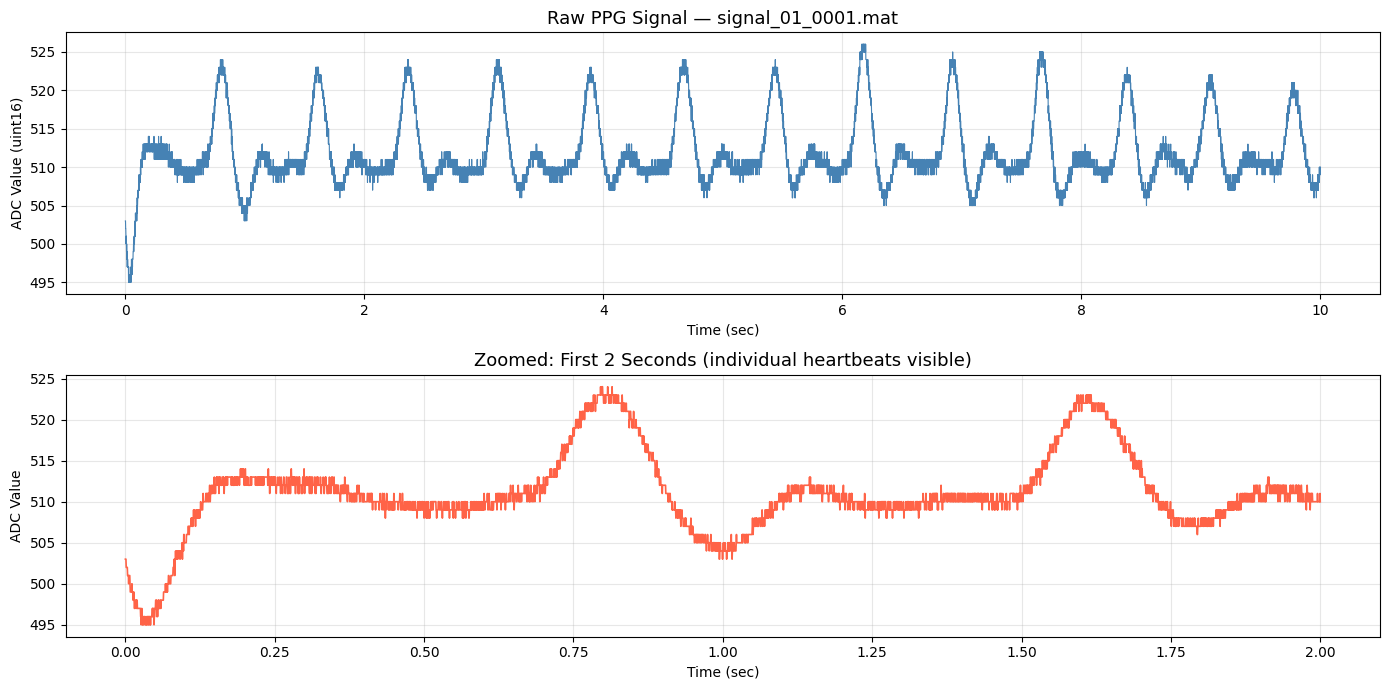

Signal stats:
  Samples   : 21900
  Min       : 495.0
  Max       : 526.0
  Range     : 31.0
  Mean      : 511.87
  Std       : 4.51


In [10]:
mat    = sio.loadmat(signal_files[0])
signal = mat['signal'].flatten().astype(float)
time   = np.arange(len(signal)) / FS

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

# ── Top: Raw signal ──
axes[0].plot(time, signal, color='steelblue', linewidth=0.8)
axes[0].set_title(f'Raw PPG Signal — {os.path.basename(signal_files[0])}', fontsize=13)
axes[0].set_xlabel('Time (sec)')
axes[0].set_ylabel('ADC Value (uint16)')
axes[0].grid(True, alpha=0.3)

# ── Bottom: First 2 seconds zoom ──
mask = time <= 2.0
axes[1].plot(time[mask], signal[mask], color='tomato', linewidth=1.2)
axes[1].set_title('Zoomed: First 2 Seconds (individual heartbeats visible)', fontsize=13)
axes[1].set_xlabel('Time (sec)')
axes[1].set_ylabel('ADC Value')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quick stats
print('Signal stats:')
print(f'  Samples   : {len(signal)}')
print(f'  Min       : {signal.min()}')
print(f'  Max       : {signal.max()}')
print(f'  Range     : {signal.max() - signal.min()}')
print(f'  Mean      : {signal.mean():.2f}')
print(f'  Std       : {signal.std():.2f}')

## Cell 8 — Compare Signals Across Subjects

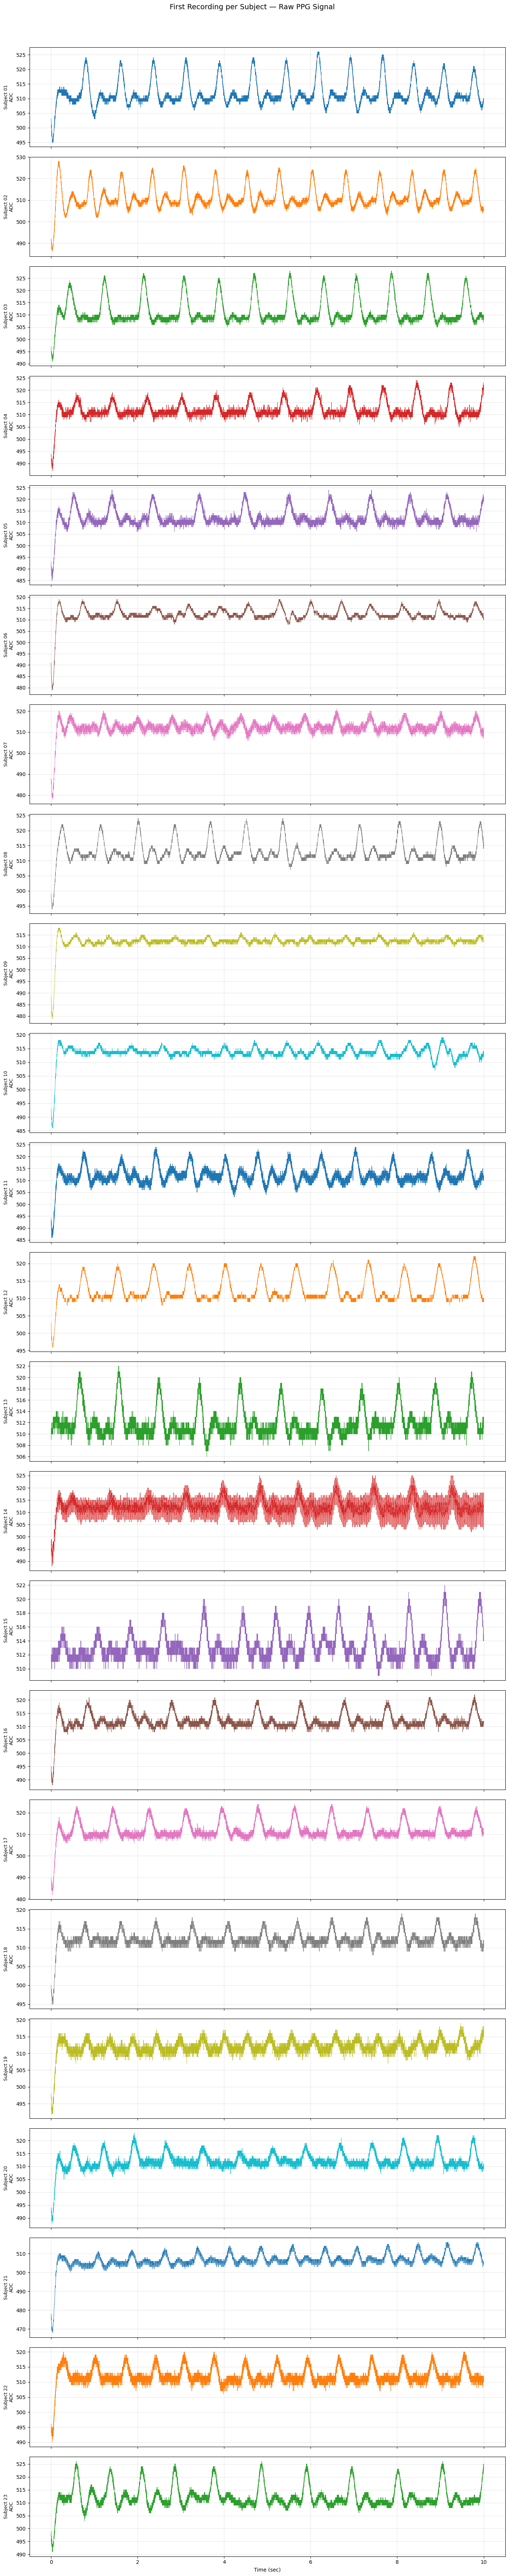

In [11]:
# Plot first recording from each subject side by side
first_per_subject = {}
for f in signal_files:
    subj, rec = parse_id(f)
    if subj not in first_per_subject:
        first_per_subject[subj] = f

n_subj = len(first_per_subject)
fig, axes = plt.subplots(n_subj, 1, figsize=(14, 3 * n_subj), sharex=True)
if n_subj == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for i, (subj, fpath) in enumerate(sorted(first_per_subject.items())):
    mat    = sio.loadmat(fpath)
    sig    = mat['signal'].flatten().astype(float)
    t      = np.arange(len(sig)) / FS
    axes[i].plot(t, sig, color=colors[i % 10], linewidth=0.7)
    axes[i].set_ylabel(f'Subject {subj:02d}\nADC', fontsize=9)
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (sec)')
fig.suptitle('First Recording per Subject — Raw PPG Signal', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

ECG Sampling Frequency: 1000 Hz
ECG Signal Shape: (1, 10000)
PPG Sampling Frequency: 30 Hz


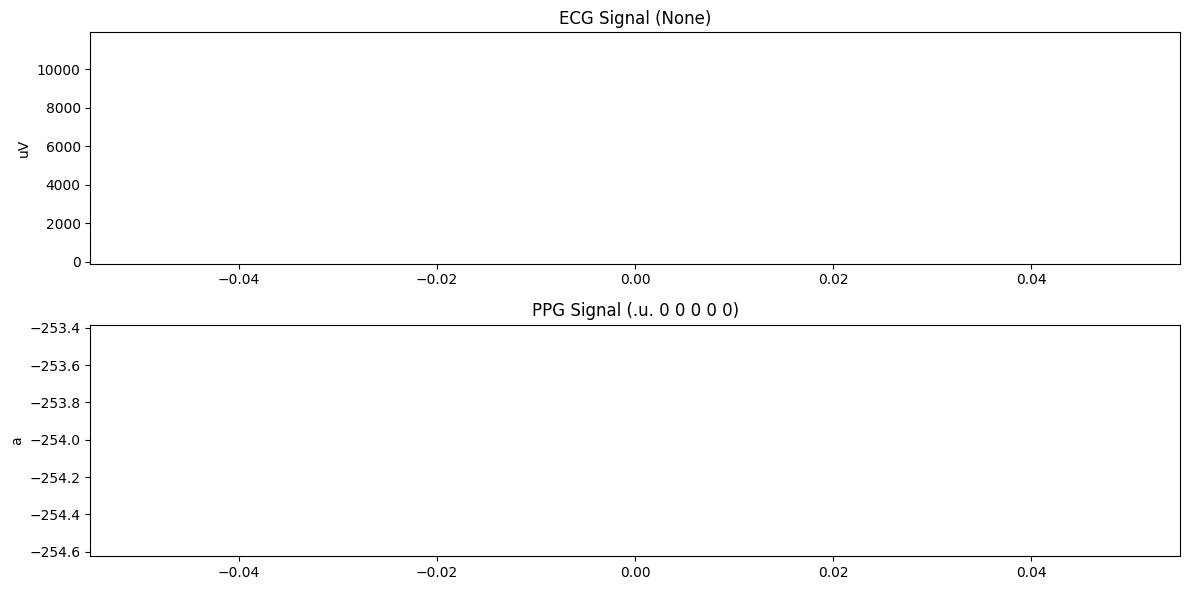

In [12]:
import wfdb
import matplotlib.pyplot as plt

# 1. Read the ECG record
# Note: Use the base name without .dat or .hea
ecg_record = wfdb.rdrecord('./brno/100002/100002_ECG')
ecg_signal = ecg_record.p_signal

# 2. Read the PPG record
ppg_record = wfdb.rdrecord('./brno/100002/100002_PPG')
ppg_signal = ppg_record.p_signal

# 3. Print metadata
print(f"ECG Sampling Frequency: {ecg_record.fs} Hz")
print(f"ECG Signal Shape: {ecg_signal.shape}")
print(f"PPG Sampling Frequency: {ppg_record.fs} Hz")

# 4. Plot a segment (first 1000 samples)
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(ecg_signal[:1000])
plt.title(f"ECG Signal ({ecg_record.sig_name[0]})")
plt.ylabel(ecg_record.units[0])

plt.subplot(2, 1, 2)
plt.plot(ppg_signal[:1000], color='red')
plt.title(f"PPG Signal ({ppg_record.sig_name[0]})")
plt.ylabel(ppg_record.units[0])

plt.tight_layout()
plt.show()

## Cell 9 — Decimate to 30 Hz (Smartphone Deployment Rate) and Re-Extract Features

`preprocess.decimate_to_30hz` uses `scipy.signal.decimate` with an FIR
anti-alias filter — not naive slicing, which would alias high-frequency
content into the pulse band. 2190 / 30 = 73 exactly, so this is a
single-stage, exact-factor decimation.

(Continuing the ML pipeline from Cells 4-6 above — Cells 7-8 and the BUT
PPG/brno cell just above this one are earlier exploratory work and are out
of scope for this feasibility study.)

In [13]:
from rppg.data import preprocess

rows_30hz = []
for r in records:
    decimated, fs_30 = preprocess.decimate_to_30hz(r['signal'], fs_in=loader.FS_NATIVE)
    feats = extractor.extract_features(decimated, fs_30)
    row = {'subject_id': r['subject_id'], 'recording_id': r['recording_id'],
           'glucose_mgdl': r['glucose_mgdl']}
    row.update(feats)
    rows_30hz.append(row)

df_30hz = pd.DataFrame(rows_30hz)
assert (df_30hz['subject_id'].values == df_native['subject_id'].values).all(), \
    'row order must match df_native for the GroupKFold folds to be comparable'

print('Feature availability comparison — fraction non-NaN:')
availability = pd.DataFrame({
    'native_2190hz': df_native[FEATURE_COLS].notna().mean(),
    'decimated_30hz': df_30hz[FEATURE_COLS].notna().mean(),
})
availability['delta'] = availability['decimated_30hz'] - availability['native_2190hz']
print(availability.round(3))

Feature availability comparison — fraction non-NaN:
                     native_2190hz  decimated_30hz  delta
pulse_rate_bpm                 1.0           1.000  0.000
hrv_rmssd_ms                   1.0           0.194 -0.806
perfusion_index                1.0           1.000  0.000
signal_quality                 1.0           1.000  0.000
rise_time_ms                   1.0           1.000  0.000
pulse_width_half_ms            1.0           1.000  0.000


In [14]:
X_30hz = df_30hz[FEATURE_COLS].values
y_30hz = df_30hz['glucose_mgdl'].values
groups_30hz = df_30hz['subject_id'].values
assert (groups_30hz == groups_native).all()

pred_baseline_30 = cross_val_predict(baseline_pipe, X_30hz, y_30hz, groups=groups_30hz, cv=gkf)
pred_ridge_30 = cross_val_predict(ridge_pipe, X_30hz, y_30hz, groups=groups_30hz, cv=gkf)
pred_rf_30 = cross_val_predict(rf_pipe, X_30hz, y_30hz, groups=groups_30hz, cv=gkf)

results_30hz = df_30hz[['subject_id', 'recording_id', 'glucose_mgdl']].copy()
results_30hz['pred_baseline'] = pred_baseline_30
results_30hz['pred_ridge'] = pred_ridge_30
results_30hz['pred_rf'] = pred_rf_30
for col in ['baseline', 'ridge', 'rf']:
    results_30hz[f'abs_err_{col}'] = (results_30hz[f'pred_{col}'] - results_30hz['glucose_mgdl']).abs()

print('Pooled MAE comparison — native 2190 Hz vs decimated 30 Hz (out-of-fold):')
comparison = pd.DataFrame({
    'native_2190hz': {c: results_native[f'abs_err_{c}'].mean() for c in ['baseline', 'ridge', 'rf']},
    'decimated_30hz': {c: results_30hz[f'abs_err_{c}'].mean() for c in ['baseline', 'ridge', 'rf']},
})
print(comparison.round(2))

print('\nPer-subject MAE (median [IQR]) — native vs 30 Hz:')
for col in ['baseline', 'ridge', 'rf']:
    s_native = metrics.summarize_per_subject(
        metrics.per_subject_mae(results_native['glucose_mgdl'], results_native[f'pred_{col}'], results_native['subject_id']))
    s_30 = metrics.summarize_per_subject(
        metrics.per_subject_mae(results_30hz['glucose_mgdl'], results_30hz[f'pred_{col}'], results_30hz['subject_id']))
    print(f'  {col:10s} native: {s_native["median"]:.2f} [{s_native["iqr_low"]:.2f}, {s_native["iqr_high"]:.2f}]   '
          f'30hz: {s_30["median"]:.2f} [{s_30["iqr_low"]:.2f}, {s_30["iqr_high"]:.2f}]')

Pooled MAE comparison — native 2190 Hz vs decimated 30 Hz (out-of-fold):
          native_2190hz  decimated_30hz
baseline          14.57           14.57
ridge             15.64           14.84
rf                16.52           15.11

Per-subject MAE (median [IQR]) — native vs 30 Hz:
  baseline   native: 13.94 [10.99, 15.96]   30hz: 13.94 [10.99, 15.96]
  ridge      native: 13.96 [12.67, 17.05]   30hz: 15.55 [11.55, 17.00]
  rf         native: 16.47 [10.77, 19.19]   30hz: 15.38 [10.39, 17.72]


## Feasibility Study, n = 23 Subjects — Read Before Interpreting Any Number Above

These results describe whether a glucose-relevant (or, more likely,
autonomic/vascular) signal survives smartphone-grade 30 Hz sampling on
`rppg/PPG_Dataset/` — 23 subjects, 67 recordings, a lab pulse sensor, not the
target Indonesian population and not a smartphone. They are:

- **A feasibility signal, not a validated accuracy claim.** With 23 subjects
  and a 5-fold GroupKFold, each fold holds out only ~4-5 people —
  underpowered to detect small effect sizes, per finding C4.
- **Bounded by n=23 subjects everywhere**, per the ring-fence rules for
  `ppg_glucose_estimate` in `docs/interface/INTERFACE_CONTRACT_v1.md`.
- **Not evidence this replaces a glucometer.** GlucoSight is a research
  prototype, not a medical device, and this signal — whatever its accuracy
  above — is a trend signal at most, never a sole prediction, never shown
  directly to a user.
- Honest about degradation: the feature-availability and MAE-comparison
  tables above report real coverage and real errors. In this run,
  `hrv_rmssd_ms` availability drops sharply from native rate to 30 Hz
  (beat-timing resolution decimation removes), while pulse rate, perfusion
  index, signal quality, and even the morphology features hold up — and at
  native rate, the population-mean baseline matches or beats both trained
  models on pooled and per-subject MAE. That is itself the reportable
  finding for this sprint (see `agents/rppg/CLAUDE.md` Task 2): no evidence
  yet of an optical glucose signal beyond autonomic/vascular features, which
  is consistent with the track's own honest expectation going in.